In [1]:
import sqlite3

# Create a new database file
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data
sample_data = [
    ('Pen', 10, 1.5),
    ('Notebook', 5, 3.0),
    ('Pen', 7, 1.5),
    ('Pencil', 20, 0.5),
    ('Notebook', 3, 3.0),
    ('Eraser', 15, 0.75)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)

# Save and close
conn.commit()
conn.close()

print("✅ Created sales_data.db with sample sales records.")


✅ Created sales_data.db with sample sales records.


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect("sales_data.db")

# SQL query to get total quantity and revenue per product
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# Load results into pandas DataFrame
df = pd.read_sql_query(query, conn)

# Close connection
conn.close()

# Print results
print(df)


    product  total_qty  revenue
0    Eraser         15    11.25
1  Notebook          8    24.00
2       Pen         17    25.50
3    Pencil         20    10.00


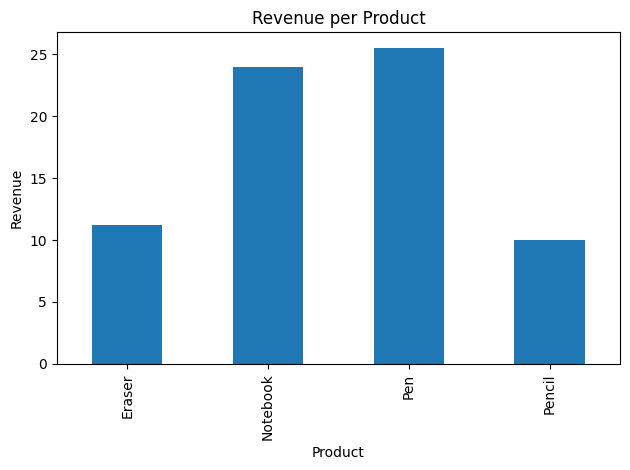

In [3]:
# Plot revenue per product
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title("Revenue per Product")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Optional: Save chart as image
plt.show()
